# Time Value of Money in Python
### CFA Level 1 Quantitative Methods | Implemented in Python

---

## What this notebook covers

The Time Value of Money (TVM) is the foundation of all finance.
Every bond price, every equity valuation, every capital budgeting 
decision starts here.

The CFA curriculum teaches you the formulas.
This notebook teaches you to implement them — in Python, 
from scratch, with real financial applications.

**By the end of this notebook you will be able to:**
- Implement PV, FV, and annuity formulas directly from the CFA definition
- Price a bond using Python
- Calculate mortgage payments
- Solve any TVM problem without a financial calculator

**Prerequisites:** Basic Python (variables, functions). No finance background beyond CFA Level 1 readings.

## Setup

We will use three libraries:
- `numpy` — for mathematical operations
- `numpy_financial` — for built-in TVM functions (industry standard)
- `matplotlib` — for visualizations

No external data needed. Everything runs locally.

In [2]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. The Core Concept

The CFA curriculum defines the Time Value of Money as:

> "A dollar today is worth more than a dollar tomorrow."

Why? Because money available today can be invested and earn a return.

This gives us two fundamental directions:

- **Compounding** → moving money *forward* in time → Future Value (FV)
- **Discounting** → moving money *backward* in time → Present Value (PV)

The master formula connecting everything:

$$PV = \frac{FV}{(1 + r)^n}$$

Where:
- $PV$ = Present Value
- $FV$ = Future Value  
- $r$ = interest rate per period
- $n$ = number of periods

This single formula is the DNA of all TVM calculations.
Everything else — annuities, perpetuities, bond pricing — 
is a variation of this.

## 2. Present Value — From Formula to Python

Let's implement the PV formula directly from the CFA definition.

**The question:**
You will receive $1,000 in 5 years.
The interest rate is 8% per year.
What is that cash flow worth today?

In [4]:
# Define the inputs
FV = 1000   # Future Value in dollars
r = 0.08    # Annual interest rate (8%)
n = 5       # Number of periods (years)

# Implement the CFA formula directly
PV = FV / (1 + r)**n # ** used to raise to an exponent

print(f"Present Value: ${PV:.2f}")
print(f"Interpretation: $1,000 received in 5 years")
print(f"is worth ${PV:.2f} today at an 8% discount rate.")

Present Value: $680.58
Interpretation: $1,000 received in 5 years
is worth $680.58 today at an 8% discount rate.


## 3. Future Value — From Formula to Python

**The question:**
You invest $1,000 today at an interest rate of 8% per year.
What will it be worth in 5 years?

$$FV = PV \times (1 + r)^n$$

Notice this is simply the PV formula rearranged.
We are now moving money *forward* in time instead of backward.

In [5]:
# Define the inputs
PV = 1000   # Present Value in dollars
r = 0.08    # Annual interest rate (8%)
n = 5       # Number of periods (years)

# Implement the CFA formula directly
FV = PV * (1 + r)**n

print(f"Future Value: ${FV:.2f}")
print(f"Interpretation: $1,000 invested today")
print(f"grows to ${FV:.2f} in 5 years at 8% per year.")

# Sanity check — discount it back
PV_check = FV / (1 + r)**n
print(f"\nSanity check — discounting FV back to today: ${PV_check:.2f}")

Future Value: $1469.33
Interpretation: $1,000 invested today
grows to $1469.33 in 5 years at 8% per year.

Sanity check — discounting FV back to today: $1000.00


## 4. Visualizing the Time Value of Money

A picture is worth a thousand formulas.

Let's visualize how $1,000 grows over time at different interest rates
— and how the same $1,000 received in the future shrinks in present value
as the discount rate increases.

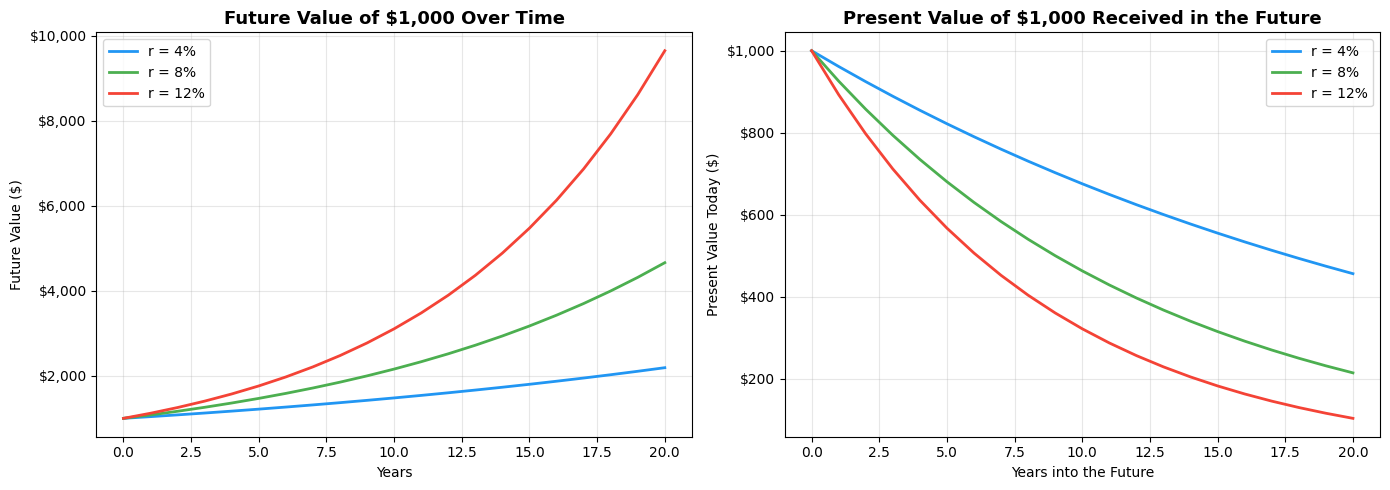

In [6]:
# Time periods
periods = np.arange(0, 21)  # 0 to 20 years
rates = [0.04, 0.08, 0.12]  # 4%, 8%, 12%
colors = ['#2196F3', '#4CAF50', '#F44336']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Future Value growth ---
for r, color in zip(rates, colors):
    FV = 1000 * (1 + r)**periods
    ax1.plot(periods, FV, color=color, linewidth=2, label=f'r = {int(r*100)}%')

ax1.set_title('Future Value of $1,000 Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Years')
ax1.set_ylabel('Future Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# --- Right plot: Present Value decay ---
for r, color in zip(rates, colors):
    PV = 1000 / (1 + r)**periods
    ax2.plot(periods, PV, color=color, linewidth=2, label=f'r = {int(r*100)}%')

ax2.set_title('Present Value of $1,000 Received in the Future', fontsize=13, fontweight='bold')
ax2.set_xlabel('Years into the Future')
ax2.set_ylabel('Present Value Today ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

## 5. Introducing numpy_financial

So far we built PV and FV from scratch.
This is important — you should always understand what is happening under the hood.

In practice, finance professionals use `numpy_financial` — 
a library that implements these calculations cleanly and efficiently.

Let's verify our results match — then move to more complex calculations
that would be tedious to implement manually.

`numpy_financial` key functions:

| Function | What it does |
|----------|-------------|
| `npf.pv()` | Present Value |
| `npf.fv()` | Future Value |
| `npf.pmt()` | Payment per period |
| `npf.nper()` | Number of periods |
| `npf.rate()` | Interest rate |

**Important:** `numpy_financial` follows a cash flow sign convention:
- Money going **out** (payments) → **negative**
- Money coming **in** (receipts) → **positive**

In [7]:
# Verify our manual calculations match numpy_financial

# Present Value verification
PV_manual = 1000 / (1 + 0.08)**5
PV_npf = npf.pv(rate=0.08, nper=5, pmt=0, fv=1000)

print("=== Present Value Verification ===")
print(f"Manual calculation:       ${PV_manual:.2f}")
print(f"numpy_financial:          ${abs(PV_npf):.2f}")
print(f"Match: {abs(round(PV_manual, 2)) == abs(round(PV_npf, 2))}")

# Future Value verification
FV_manual = 1000 * (1 + 0.08)**5
FV_npf = npf.fv(rate=0.08, nper=5, pmt=0, pv=-1000)

print("\n=== Future Value Verification ===")
print(f"Manual calculation:       ${FV_manual:.2f}")
print(f"numpy_financial:          ${FV_npf:.2f}")
print(f"Match: {round(FV_manual, 2) == round(FV_npf, 2)}")

=== Present Value Verification ===
Manual calculation:       $680.58
numpy_financial:          $680.58
Match: True

=== Future Value Verification ===
Manual calculation:       $1469.33
numpy_financial:          $1469.33
Match: True


## 6. Annuities

An annuity is a series of equal cash flows paid at regular intervals.

This is where TVM gets powerful — and where the financial calculator 
on the CFA exam gets replaced by Python in the real world.

The CFA curriculum defines two types:

- **Ordinary Annuity** — payments occur at the *end* of each period
- **Annuity Due** — payments occur at the *beginning* of each period

The Present Value of an Ordinary Annuity formula:

$$PV = PMT \times \frac{1 - (1+r)^{-n}}{r}$$

Where:
- $PMT$ = payment per period
- $r$ = interest rate per period
- $n$ = number of periods

**Real world examples:**
- Mortgage payments
- Lease payments
- Bond coupon payments
- Pension payments

In [8]:
# ============================================
# Ordinary Annuity — Manual Implementation
# ============================================

PMT = 1000   # Payment per period ($)
r = 0.08     # Interest rate per period (8%)
n = 5        # Number of periods

# CFA formula implemented directly
PV_annuity_manual = PMT * (1 - (1 + r)**(-n)) / r

print("=== Ordinary Annuity ===")
print(f"Payment per period:  ${PMT:,.2f}")
print(f"Interest rate:       {r*100:.1f}%")
print(f"Number of periods:   {n} years")
print(f"\nPV (manual):         ${PV_annuity_manual:,.2f}")

# Verify with numpy_financial
PV_annuity_npf = abs(npf.pv(rate=r, nper=n, pmt=PMT))
print(f"PV (numpy_financial): ${PV_annuity_npf:,.2f}")
print(f"Match: {round(PV_annuity_manual, 2) == round(PV_annuity_npf, 2)}")

# ============================================
# Annuity Due — payments at beginning of period
# ============================================
print("\n=== Annuity Due ===")
PV_annuity_due = PV_annuity_manual * (1 + r)
PV_annuity_due_npf = abs(npf.pv(rate=r, nper=n, pmt=PMT, when='begin'))

print(f"PV (manual):          ${PV_annuity_due:,.2f}")
print(f"PV (numpy_financial): ${PV_annuity_due_npf:,.2f}")
print(f"\nDifference from ordinary annuity: ${PV_annuity_due - PV_annuity_manual:,.2f}")
print("(Annuity Due is always worth more — payments arrive earlier)")

=== Ordinary Annuity ===
Payment per period:  $1,000.00
Interest rate:       8.0%
Number of periods:   5 years

PV (manual):         $3,992.71
PV (numpy_financial): $3,992.71
Match: True

=== Annuity Due ===
PV (manual):          $4,312.13
PV (numpy_financial): $4,312.13

Difference from ordinary annuity: $319.42
(Annuity Due is always worth more — payments arrive earlier)


## 7. Real Application — Mortgage Calculator

Let's apply everything we've learned to a real problem.

A mortgage is simply an ordinary annuity — 
you borrow money today and repay it in equal monthly installments.

**The question:**
You are buying an apartment in Paris for €500,000.
You make a 20% down payment.
The bank offers you a 25-year mortgage at 3.5% annual interest.

**What is your monthly payment?**

This is exactly the type of problem that appears in CFA exams
— and exactly what finance professionals calculate daily.

In [9]:
# ============================================
# Mortgage Calculator
# ============================================

# Inputs
property_price = 500_000      # €500,000 apartment
down_payment_pct = 0.20       # 20% down payment
annual_rate = 0.035           # 3.5% annual interest
years = 25                    # 25-year mortgage

# Derived inputs
down_payment = property_price * down_payment_pct
loan_amount = property_price - down_payment
monthly_rate = annual_rate / 12
n_payments = years * 12

print("=== Mortgage Summary ===")
print(f"Property price:      €{property_price:>12,.2f}")
print(f"Down payment (20%):  €{down_payment:>12,.2f}")
print(f"Loan amount:         €{loan_amount:>12,.2f}")
print(f"Annual rate:         {annual_rate*100:.1f}%")
print(f"Monthly rate:        {monthly_rate*100:.4f}%")
print(f"Number of payments:  {n_payments}")

# Monthly payment using numpy_financial
monthly_payment = abs(npf.pmt(rate=monthly_rate, nper=n_payments, pv=loan_amount))

print(f"\n=== Results ===")
print(f"Monthly payment:     €{monthly_payment:>12,.2f}")
print(f"Total paid:          €{monthly_payment * n_payments:>12,.2f}")
print(f"Total interest paid: €{(monthly_payment * n_payments) - loan_amount:>12,.2f}")
print(f"Interest as % of loan: {((monthly_payment * n_payments - loan_amount) / loan_amount)*100:.1f}%")

=== Mortgage Summary ===
Property price:      €  500,000.00
Down payment (20%):  €  100,000.00
Loan amount:         €  400,000.00
Annual rate:         3.5%
Monthly rate:        0.2917%
Number of payments:  300

=== Results ===
Monthly payment:     €    2,002.49
Total paid:          €  600,748.28
Total interest paid: €  200,748.28
Interest as % of loan: 50.2%


## 8. Amortization Schedule

The monthly payment is €2,001.18 every month for 25 years.
But what exactly are you paying for each month?

Every mortgage payment has two components:
- **Interest** — what the bank charges you for the loan
- **Principal** — what reduces your actual debt

In the early years you pay mostly interest.
In the later years you pay mostly principal.

This is called an **amortization schedule** — 
and it is one of the most important concepts in fixed income.

Let's build it from scratch.

=== Amortization Schedule (First 6 Months) ===
 Month      Payment    Principal     Interest        Balance
------------------------------------------------------------
     1 €  2,002.49 €    835.83 €  1,166.67 €  399,164.17
     2 €  2,002.49 €    838.27 €  1,164.23 €  398,325.91
     3 €  2,002.49 €    840.71 €  1,161.78 €  397,485.20
     4 €  2,002.49 €    843.16 €  1,159.33 €  396,642.03
     5 €  2,002.49 €    845.62 €  1,156.87 €  395,796.41
     6 €  2,002.49 €    848.09 €  1,154.41 €  394,948.32

...

=== Amortization Schedule (Last 3 Months) ===
 Month      Payment    Principal     Interest        Balance
------------------------------------------------------------
   298 €  2,002.49 €  1,985.07 €     17.42 €    3,987.53
   299 €  2,002.49 €  1,990.86 €     11.63 €    1,996.67
   300 €  2,002.49 €  1,996.67 €      5.82 €        0.00


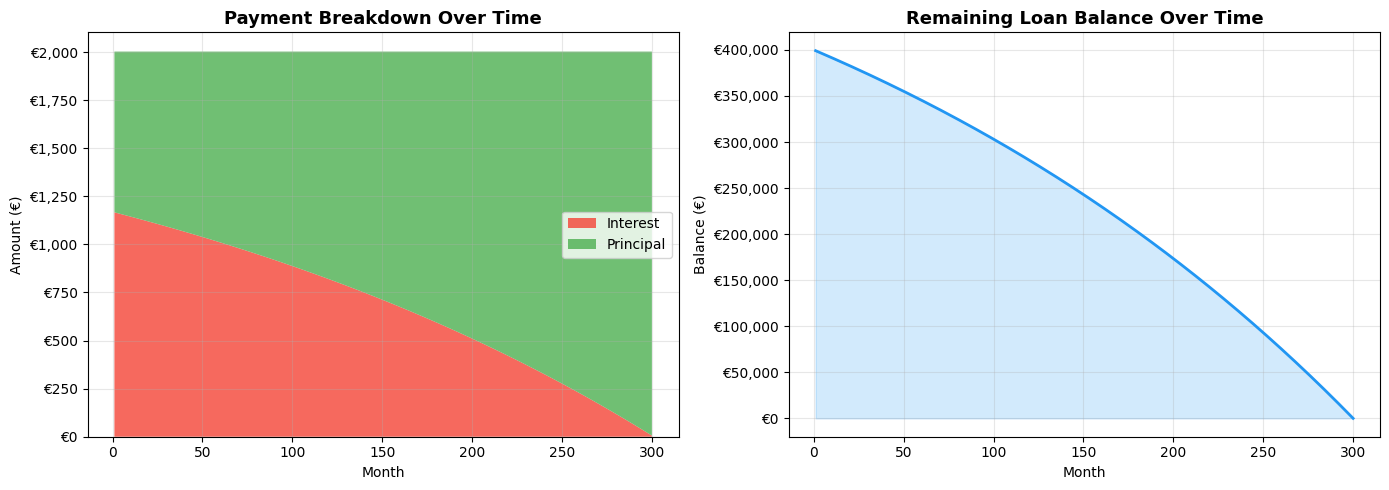


Key insight: You pay more interest than principal
for the first 64 months (5 years and 4 months).


In [12]:
# ============================================
# Full Amortization Schedule
# ============================================

# Initialize
balance = loan_amount
schedule = []

for month in range(1, n_payments + 1):
    # Interest component this month
    interest_payment = balance * monthly_rate
    
    # Principal component this month
    principal_payment = monthly_payment - interest_payment
    
    # Remaining balance
    balance -= principal_payment
    
    schedule.append({
        'Month': month,
        'Payment': monthly_payment,
        'Principal': principal_payment,
        'Interest': interest_payment,
        'Balance': max(balance, 0)  # avoid floating point negatives
    })

# Convert to arrays for plotting
months = [s['Month'] for s in schedule]
principal_payments = [s['Principal'] for s in schedule]
interest_payments = [s['Interest'] for s in schedule]
balances = [s['Balance'] for s in schedule]

# Print first 6 months and last 3 months
print("=== Amortization Schedule (First 6 Months) ===")
print(f"{'Month':>6} {'Payment':>12} {'Principal':>12} {'Interest':>12} {'Balance':>14}")
print("-" * 60)
for s in schedule[:6]:
    print(f"{s['Month']:>6} €{s['Payment']:>10,.2f} €{s['Principal']:>10,.2f} €{s['Interest']:>10,.2f} €{s['Balance']:>12,.2f}")

print("\n...")

print(f"\n=== Amortization Schedule (Last 3 Months) ===")
print(f"{'Month':>6} {'Payment':>12} {'Principal':>12} {'Interest':>12} {'Balance':>14}")
print("-" * 60)
for s in schedule[-3:]:
    print(f"{s['Month']:>6} €{s['Payment']:>10,.2f} €{s['Principal']:>10,.2f} €{s['Interest']:>10,.2f} €{s['Balance']:>12,.2f}")

# ============================================
# Visualization
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left — Principal vs Interest over time
ax1.stackplot(months, interest_payments, principal_payments,
              labels=['Interest', 'Principal'],
              colors=['#F44336', '#4CAF50'], alpha=0.8)
ax1.set_title('Payment Breakdown Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Amount (€)')
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Right — Remaining balance over time
ax2.plot(months, balances, color='#2196F3', linewidth=2)
ax2.fill_between(months, balances, alpha=0.2, color='#2196F3')
ax2.set_title('Remaining Loan Balance Over Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Balance (€)')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.tight_layout()
plt.show()

# Key insight
crossover = next(s['Month'] for s in schedule if s['Principal'] > s['Interest'])
print(f"\nKey insight: You pay more interest than principal")
print(f"for the first {crossover} months ({crossover//12} years and {crossover%12} months).")

## 9. CFA Exam Style Practice Problems

Now let's put everything together.

The following problems are written in CFA exam style.
Try to solve each one yourself first — then run the code to verify.

---

### Problem 1
An investor deposits €5,000 into a savings account today.
The account pays 6% interest compounded annually.
How much will the investor have after 10 years?

### Problem 2
A company will need €250,000 in 8 years to replace equipment.
The company can earn 7% annually on its investments.
How much must the company invest today?

### Problem 3
An investor is evaluating an annuity that pays €3,000
at the end of each year for 10 years.
The required rate of return is 9%.
What is the maximum price the investor should pay for this annuity?

---

*Try each one before running the solution cell below.*

In [13]:
# ============================================
# Problem 1 — Future Value
# ============================================
print("=" * 55)
print("PROBLEM 1 — Future Value")
print("=" * 55)

PV = 5_000
r = 0.06
n = 10

FV = PV * (1 + r)**n
FV_npf = npf.fv(rate=r, nper=n, pmt=0, pv=-PV)

print(f"Given:  PV = €{PV:,.2f}, r = {r*100:.0f}%, n = {n} years")
print(f"Formula: FV = PV × (1 + r)^n")
print(f"FV = €{PV:,} × (1.06)^{n}")
print(f"\nAnswer: €{FV:,.2f}")
print(f"Verify: €{FV_npf:,.2f}")

# ============================================
# Problem 2 — Present Value
# ============================================
print(f"\n{'=' * 55}")
print("PROBLEM 2 — Present Value")
print("=" * 55)

FV = 250_000
r = 0.07
n = 8

PV = FV / (1 + r)**n
PV_npf = abs(npf.pv(rate=r, nper=n, pmt=0, fv=FV))

print(f"Given:  FV = €{FV:,.2f}, r = {r*100:.0f}%, n = {n} years")
print(f"Formula: PV = FV / (1 + r)^n")
print(f"PV = €{FV:,} / (1.07)^{n}")
print(f"\nAnswer: €{PV:,.2f}")
print(f"Verify: €{PV_npf:,.2f}")
print(f"Interpretation: Invest €{PV:,.2f} today to have €{FV:,} in {n} years.")

# ============================================
# Problem 3 — Present Value of Annuity
# ============================================
print(f"\n{'=' * 55}")
print("PROBLEM 3 — Present Value of Ordinary Annuity")
print("=" * 55)

PMT = 3_000
r = 0.09
n = 10

PV_annuity = PMT * (1 - (1 + r)**(-n)) / r
PV_annuity_npf = abs(npf.pv(rate=r, nper=n, pmt=PMT))

print(f"Given:  PMT = €{PMT:,.2f}, r = {r*100:.0f}%, n = {n} years")
print(f"Formula: PV = PMT × [1 - (1+r)^-n] / r")
print(f"\nAnswer: €{PV_annuity:,.2f}")
print(f"Verify: €{PV_annuity_npf:,.2f}")
print(f"\nInterpretation: Never pay more than €{PV_annuity:,.2f} for this annuity.")
print(f"At this price your return is exactly 9%.")
print(f"Pay less → return above 9%. Pay more → return below 9%.")

PROBLEM 1 — Future Value
Given:  PV = €5,000.00, r = 6%, n = 10 years
Formula: FV = PV × (1 + r)^n
FV = €5,000 × (1.06)^10

Answer: €8,954.24
Verify: €8,954.24

PROBLEM 2 — Present Value
Given:  FV = €250,000.00, r = 7%, n = 8 years
Formula: PV = FV / (1 + r)^n
PV = €250,000 / (1.07)^8

Answer: €145,502.28
Verify: €145,502.28
Interpretation: Invest €145,502.28 today to have €250,000 in 8 years.

PROBLEM 3 — Present Value of Ordinary Annuity
Given:  PMT = €3,000.00, r = 9%, n = 10 years
Formula: PV = PMT × [1 - (1+r)^-n] / r

Answer: €19,252.97
Verify: €19,252.97

Interpretation: Never pay more than €19,252.97 for this annuity.
At this price your return is exactly 9%.
Pay less → return above 9%. Pay more → return below 9%.


## 10. Key Takeaways

---

### What you learned in this notebook

| Concept | Formula | Python |
|---------|---------|--------|
| Present Value | $PV = FV / (1+r)^n$ | `npf.pv()` |
| Future Value | $FV = PV × (1+r)^n$ | `npf.fv()` |
| Annuity Payment | $PV = PMT × \frac{1-(1+r)^{-n}}{r}$ | `npf.pmt()` |

---

### The three things to remember

**1. PV and FV are the same formula rearranged.**
You are always just moving money forward or backward in time.

**2. The discount rate is everything.**
A small change in r creates a large change in value — 
especially over long time horizons. Always stress test your rate.

**3. Annuities are just repeated PV calculations.**
Once you understand single cash flow discounting,
annuities are a natural extension — not a new concept.

---

### What comes next

This notebook is Part 1 of the CFA Level 1 Quantitative Methods in Python series.

| Notebook | Topic |
|----------|-------|
| ✅ Part 1 | Time Value of Money |
| 🔜 Part 2 | Statistical Concepts & Distributions |
| 🔜 Part 3 | Probability & Expected Returns |
| 🔜 Part 4 | Hypothesis Testing |
| 🔜 Part 5 | Linear Regression |
| 🔜 Part 6 | Big Data & Machine Learning in Finance |

---

### Found this useful?

⭐ Star this repository on GitHub

Share it with a CFA candidate who is struggling with Quant Methods.

All notebooks are free. Always.